In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

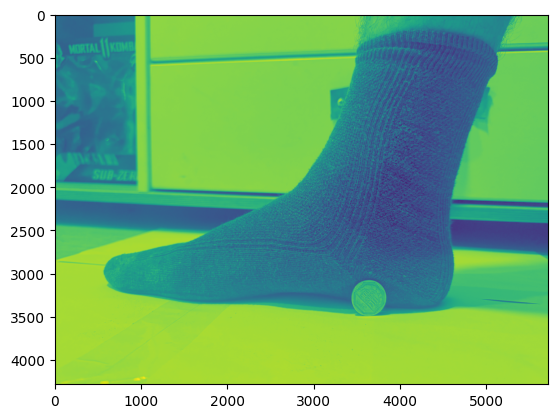

In [5]:
photo_path = f"../assets/my_foot.png"

image = cv2.imread(photo_path)

image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray)
plt.show()


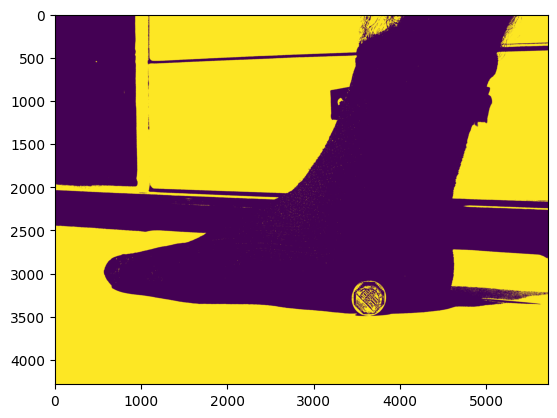

In [7]:
_, binary = cv2.threshold(image_gray, 127, 255, cv2.THRESH_BINARY)
plt.imshow(binary)
plt.show()

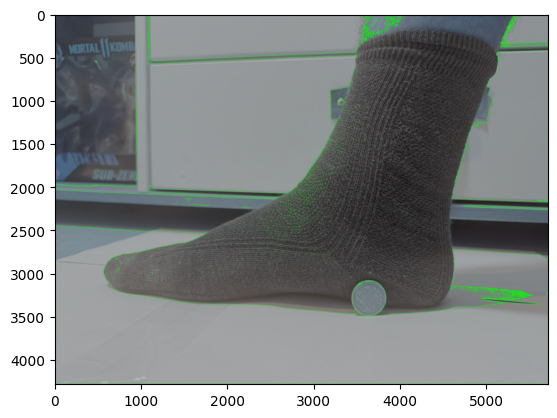

In [9]:
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_with_contours = cv2.drawContours(image.copy(), contours, -1, (0, 255, 0), 2)
plt.imshow(img_with_contours)
plt.show()

In [16]:
filtered_contours = []
for contour in contours:
    area = cv2.contourArea(contour)
    if area > 100:
        filtered_contours.append(contour)

len(filtered_contours)

34

In [17]:
centroids = []
for contour in filtered_contours:
    moment = cv2.moments(contour)
    if moment["m00"] != 0:
        cX = int(moment["m10"] / moment["m00"])
        cY = int(moment["m01"] / moment["m00"])
        #print(f"Centroid at ({cX}, {cY})")
        cv2.circle(image, (cX, cY), 5, (255, 0, 0), 1)
        centroids.append((cX, cY))

print(f"Detected centroids: {centroids}")

Detected centroids: [(5385, 3228), (2732, 3637), (5234, 2240), (1708, 2212), (3298, 1007), (478, 551), (5278, 1399), (5220, 370), (5471, 359), (3554, 328), (3605, 291), (3563, 290), (3591, 280), (5195, 273), (3571, 256), (3688, 229), (3581, 217), (3680, 224), (5242, 151), (3951, 126), (5261, 146), (5282, 93), (3860, 109), (3894, 88), (5301, 59), (3922, 12), (5481, 181), (5324, 20), (3997, 4), (3960, 49), (3875, 31), (3728, 113), (2284, 244), (2025, 1251)]


In [20]:
coin_centroid = None
foot_centroid = None

for contour in filtered_contours:
    perimeter = cv2.arcLength(contour, True)
    circularity = 4 * np.pi * cv2.contourArea(contour) / (perimeter**2)
    if 0.8 < circularity < 1.2:  # Adjust thresholds for circular objects like coins
        coin_centroid = (cX, cY)
    else:
        foot_centroid = (cX, cY)

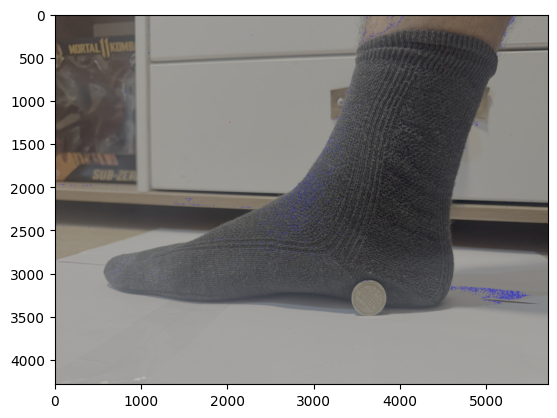

In [23]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

if coin_centroid:
    cv2.circle(image_rgb, coin_centroid, 5, (0, 255, 0), -1)  # Green for coin
if foot_centroid:
    cv2.circle(image_rgb, foot_centroid, 5, (255, 0, 0), -1)  # Blue for foot

# Display the result
#img_centroids = cv2.imshow('Detected Centroids', image)

plt.imshow(image_rgb)
plt.show()

## Using YOLO with a pretrained model

In [9]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [11]:
photo_path = f"../assets/doris_foot_cropped.png"
image = cv2.imread(photo_path)

model = YOLO('yolov8n.pt')

results = model.predict(photo_path)


image 1/1 /Users/gipo/my-stuff/MIT/shoe-sizer/experiments/../assets/doris_foot_cropped.png: 256x640 1 sports ball, 17.8ms
Speed: 0.8ms preprocess, 17.8ms inference, 0.4ms postprocess per image at shape (1, 3, 256, 640)


In [32]:
names = results[0].names
names
#'coin' in names.values()

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [13]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([32.])
conf: tensor([0.3297])
data: tensor([[1.4886e+03, 7.1785e+02, 1.8990e+03, 1.1293e+03, 3.2970e-01, 3.2000e+01]])
id: None
is_track: False
orig_shape: (1468, 4020)
shape: torch.Size([1, 6])
xywh: tensor([[1693.8103,  923.5577,  410.3566,  411.4185]])
xywhn: tensor([[0.4213, 0.6291, 0.1021, 0.2803]])
xyxy: tensor([[1488.6321,  717.8484, 1898.9886, 1129.2670]])
xyxyn: tensor([[0.3703, 0.4890, 0.4724, 0.7693]])

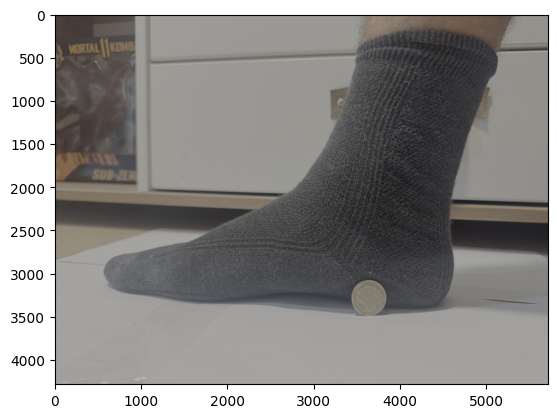

In [32]:
detections = results[0].boxes.xyxy
labels = results[0].boxes.cls
scores = results[0].boxes.conf

foot_centroid = None
coin_centroid = None
foot_class_id = 1 # Person
coin_class_id = 41 # Coin

for i, (box, label, score) in enumerate(zip(detections, labels, scores)):
    if score > 0.5:
        x1, y1, x2, y2 = box
        cX = int((x1 + x2) / 2)
        cY = int((y1 + y2) / 2)

        if label == foot_class_id:
            foot_class_id = (cX, cY)
        elif label == coin_class_id:
            coin_centroid = (cX, cY)

image = cv2.imread(photo_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

if foot_centroid:
    cv2.circle(image, foot_centroid, 5, (255, 0, 0), -1) # Blue for foot
if coin_centroid:
    cv2.circle(image, coin_centroid, 5, (0, 255, 0), 1) # Green for coin

plt.imshow(image_rgb)
plt.show()

In [33]:
print(coin_centroid)
print(foot_centroid)

None
None


## Finetuning the YOLO model

In [20]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

import matplotlib
#matplotlib.rcParams['figure.figsize'] = (10.0, 10.)
#matplotlib.rcParams['image.cmap'] = 'gray'

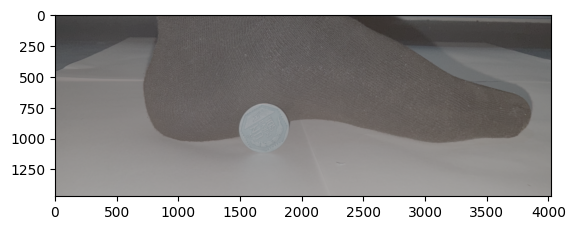

In [21]:
photo_path = f"../assets/doris_foot_cropped.png"
image = cv2.imread(photo_path)
plt.imshow(image)
plt.show()

In [ ]:
%pip install -U ultralytics

In [ ]:
from ultralytics import YOLO

photo_path = f"../assets/doris_foot_cropped.png"
# image = cv2.imread(photo_path)

model = YOLO('yolov8n.pt')

results = model.train(data='data.yaml', epochs=70, imgsz=1500, device='mps')


image 1/1 /Users/gipo/my-stuff/MIT/shoe-sizer/experiments/../assets/gian_foot_cropped.png: 864x1600 1 coin, 3 foots, 3192.3ms
Speed: 309.0ms preprocess, 3192.3ms inference, 876.5ms postprocess per image at shape (1, 3, 864, 1600)


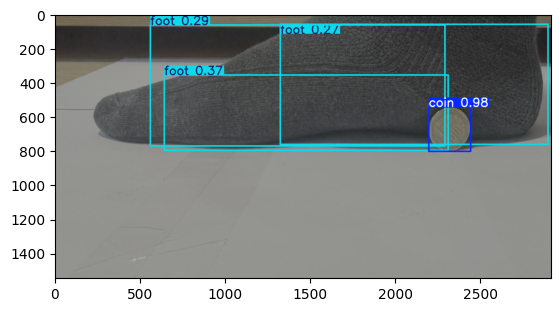

In [71]:
photo_path = f"../assets/gian_foot_cropped.png"
#photo_path = f"../assets/gian_foot_cropped.png"
new_results = model(photo_path)
new_image = cv2.imread(photo_path)

# Convert the image to RGB (YOLO outputs are in BGR)
annotated_image = new_results[0].plot()  # Annotated image from YOLO
annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

# Plot with matplotlib
#plt.figure(figsize=(10, 10))
plt.imshow(annotated_image)
plt.axis('on')
plt.show()

In [74]:
new_results[0].show()

In [83]:
def plot_pred_resutls(inf_results):
    plot_resutls = inf_results[0].plot()
    inf_image = cv2.cvtColor(plot_resutls, cv2.COLOR_BGR2RGB)
    plt.imshow(inf_image)
    plt.axis('on')
    plt.show()


image 1/1 /Users/gipo/my-stuff/MIT/shoe-sizer/experiments/../assets/my_foot.png: 1216x1600 1 coin, 2 foots, 184.4ms
Speed: 16.5ms preprocess, 184.4ms inference, 9.0ms postprocess per image at shape (1, 3, 1216, 1600)


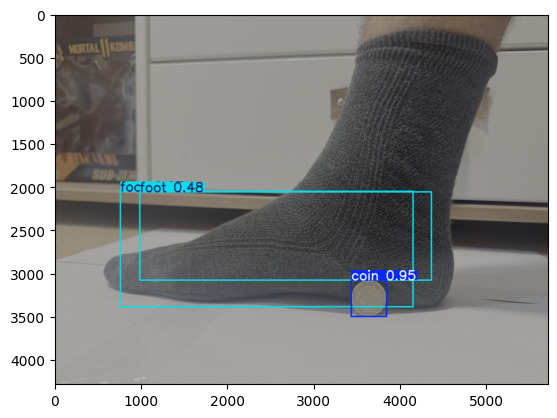

In [84]:
# Cargar los pesos entrenados
custom_model = YOLO("runs/detect/train20/weights/best.pt")

inf_results = custom_model("../assets/my_foot.png")

# Realizar inferencia
plot_pred_resutls(inf_results)


image 1/1 /Users/gipo/my-stuff/MIT/shoe-sizer/experiments/../assets/paulo_foot_cropped_light.jpeg: 1152x1504 1 coin, 1 foot, 141.2ms
Speed: 9.4ms preprocess, 141.2ms inference, 1.4ms postprocess per image at shape (1, 3, 1152, 1504)


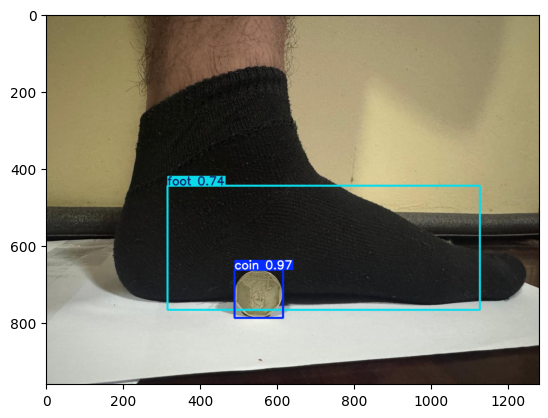

In [91]:
custom_model = YOLO("../runs/detect/train2/weights/best.pt")
inf_results = custom_model("../assets/paulo_foot_cropped_light.jpeg")
# Realizar inferencia
plot_pred_resutls(inf_results)